In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
%matplotlib inline

from torch.utils.data import DataLoader, Dataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders
import tiktoken


class BaseTokenizer:
    def encode(self, text):
        raise NotImplementedError("Subclasses should implement this!")

    def decode(self, token_ids):
        raise NotImplementedError("Subclasses should implement this!")
    
    def get_pad_token(self):
        raise NotImplementedError("Subclasses should implement this!")



class TikTokenizer(BaseTokenizer):
    def __init__(self, model_name="gpt2"):
        super().__init__()
        self.tokenizer = tiktoken.get_encoding(model_name)
        self.vocab_size = self.tokenizer.n_vocab
        self.pad_token_id = self.vocab_size  # add pad token manually
        print(f"Vocab size: {self.vocab_size}")
        
    def encode(self, text, pad=False):
        ids = self.tokenizer.encode(text)
        return ids

    def decode(self, token_ids):
        token_ids = [i for i in token_ids if i != self.pad_token_id]
        return self.tokenizer.decode(token_ids)

    def get_pad_token(self):
        return self.pad_token_id
    

class MyTokenizer(BaseTokenizer):
    def __init__(self, data):
        super().__init__()
        chars = sorted(set(data))
        self.vocab_size = len(chars)
        print(f"Vocab size: {self.vocab_size}")

        # Create a mapping from characters to indices and vice versa
        char_to_idx = {ch: i for i, ch in enumerate(chars)}
        idx_to_char = {i: ch for i, ch in enumerate(chars)}
        self.encoder = lambda s: [char_to_idx[c] for c in s]
        self.decoder = lambda l: ''.join([idx_to_char[i] for i in l])

    def encode(self, text):
        return self.encoder(text)

    def decode(self, token_ids):
        return self.decoder(token_ids)
    
    def get_pad_token(self):
        return None


class WordPieceTokenizer(BaseTokenizer):
    def __init__(self, texts, vocab_size, max_length=None):
        super().__init__()
        self.tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))
        self.tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
        self.tokenizer.decoder = decoders.WordPiece(prefix="##")
        self.tokenizer.enable_padding(pad_id=0, pad_token="[PAD]")
        
        trainer = trainers.WordPieceTrainer(vocab_size=vocab_size, special_tokens=["[PAD]", "[UNK]", "[NEWLINE]"])
        self.tokenizer.train_from_iterator(texts, trainer)

        self.vocab_size = self.tokenizer.get_vocab_size()
        self.max_length = max_length
        print(f"Vocab size: {self.vocab_size}")

    def encode(self, text, pad=False):
        text = text.replace('\n', ' [NEWLINE] ')
        enc = self.tokenizer.encode(text)
        if self.max_length:
            enc.truncate(max_length=self.max_length)
            if pad:
                enc.pad(length=self.max_length, pad_id=0, pad_token="[PAD]")
        return enc.ids

    def decode(self, ids):
        if isinstance(ids, torch.Tensor):
            ids = ids.tolist()
        txt = self.tokenizer.decode(ids, skip_special_tokens=False)
        txt = txt.replace(" [NEWLINE] ", '\n')
        txt = txt.replace(" [NEWLINE]", '\n')
        txt = txt.replace("[NEWLINE] ", '\n')
        return txt

    def get_pad_token(self):
        return 0


class CharDataset(Dataset):
    def __init__(self, data, block_size):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        return self.data[idx:idx + self.block_size], \
            self.data[idx + 1:idx + self.block_size + 1]


In [4]:
with open("data/output_chat.txt") as f:
# with open("data/tiny_shakespeare.txt") as f:
# with open("data/ghazals/ghazals.txt") as f:
    data = f.read()

print(f"Length of dataset in characters: {len(data)}")

Length of dataset in characters: 571276


In [5]:
# tokenizer = TransformerTokenizer(model_name="gpt2")
# tokenizer = TikTokenizer(model_name="gpt2", max_length=block_size)
lines_with_special_newline = [line + "[NEWLINE]" for line in data.splitlines() if line.strip()]
tokenizer = WordPieceTokenizer(lines_with_special_newline, vocab_size=3000)




Vocab size: 3000


In [6]:
# Testing the tokenizer
S = '''Thy lord is my shepherd, I shall not want.'''
# S = "A"
encoded = tokenizer.encode(S)
print(encoded, len(encoded))
print(tokenizer.decode(encoded))

[2782, 386, 719, 393, 372, 750, 1041, 2920, 1171, 622, 372, 14, 43, 786, 686, 1081, 1924, 16] 18
Thy lord is my shepherd, I shall not want.


In [7]:
# Hyperparameter
block_size = 128  # Length of each sequence

encoded_data = tokenizer.encode(data, pad=False)
print(f"Length of encoded data: {len(encoded_data)}")
print(f"Compression ratio: {len(encoded_data)*100 / len(data):.2f}%")

n1 = int(len(encoded_data) * 0.8)
n2 = int(len(encoded_data) * 0.9)

train_data  = torch.tensor(encoded_data[:n1], dtype=torch.long, device=device)
val_data    = torch.tensor(encoded_data[n1:n2], dtype=torch.long, device=device)
test_data   = torch.tensor(encoded_data[n2:], dtype=torch.long, device=device)

train_dataset   = CharDataset(train_data, block_size)
val_dataset     = CharDataset(val_data, block_size)
test_dataset    = CharDataset(test_data, block_size)

print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Length of encoded data: 207493
Compression ratio: 36.32%
Train: 165866
Validation: 20621
Test: 20622


In [8]:
import math
from torch.optim.lr_scheduler import LambdaLR

class LSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        proj_size = emb_dim // 2
        self.embedding = nn.Embedding(vocab_size, emb_dim) # One-hot encoding
        self.lstm = nn.LSTM(emb_dim, emb_dim, num_layers=2, dropout=0.3, batch_first=True, \
                            proj_size=proj_size)
        self.ln = nn.LayerNorm(proj_size)  # Layer normalization
        self.fc = nn.Sequential(
            nn.Linear(proj_size, proj_size * 4),
            nn.ReLU(),
            nn.Linear(proj_size * 4, vocab_size)
        )

    def forward(self, x, targets=None):
        emd = self.embedding(x)  # One-hot encoding
        out, _ = self.lstm(emd)  # RNN layer
        # Take the last time step's output
        # out = out[:, -1, :]
        out = self.ln(out)  # Layer normalization
        out = self.fc(out) # (B, T, C)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(out.view(-1, out.shape[-1]),
                                   targets.view(-1), 
                                   ignore_index=tokenizer.get_pad_token())
        return out, loss


@torch.no_grad()
def evaluate(model, split="val"):
    dataset = val_dataset if split == "val" else test_dataset
    loader = DataLoader(dataset, batch_size=1024, shuffle=False)
    avg_loss = 0.0
    num_correct = 0
    for batch_idx, (x, y) in enumerate(loader):
        logits, loss = model(x, y)
        avg_loss += loss / len(loader)
        num_correct += (logits[:, -1, :].argmax(dim=1) == y[:, -1]).sum().item()
    return avg_loss.item(), num_correct*100 / len(loader.dataset)


def get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))  # cosine decay
    return LambdaLR(optimizer, lr_lambda)


def get_last_non_pad_tokens(y, pad_token_id):
    if pad_token_id is None:
        return y[:, -1]  # fallback to last token
    mask = (y != pad_token_id).int()
    last_non_pad_indices = (mask.flip(dims=[1]).argmax(dim=1))
    last_positions = y.size(1) - 1 - last_non_pad_indices
    return y[torch.arange(y.size(0)), last_positions]


In [9]:
vocab_size = tokenizer.vocab_size  # Number of unique characters in the dataset
print(f"vocab_size: {vocab_size}")

# Initialize the model
model = LSTM(vocab_size=vocab_size, emb_dim=128)
model.to(device)

print(model)
print(f"Number of model params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

vocab_size: 3000
LSTM(
  (embedding): Embedding(3000, 128)
  (lstm): LSTM(128, 128, proj_size=64, num_layers=2, batch_first=True, dropout=0.3)
  (ln): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=3000, bias=True)
  )
)
Number of model params: 1.35M


In [10]:
# TESTING THE MODEL
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

# Example: Iterate through the DataLoader once
for batch_idx, (x, y) in enumerate(train_loader):
    print(f"x: {x}")
    print(f"y: {y}")
    print(f"x.shape: {x.shape}")
    print(f"y.shape: {y.shape}")

    print(f"Decoded x:\n{tokenizer.decode(x[0])}")
    print(f"Decoded y:\n{tokenizer.decode(y[0])}")
    
    logits, _ = model(x)
    
    print(f"Out shape = {logits.shape}")
    break

x: tensor([[2209,   17,   18,  405,   17, 2539,   63, 1949, 2345,   28, 1684,  402,
          833,  390,   26,   15,   27, 2752,   10,  696, 2807, 1650,  649, 1180,
         2757,  714, 2763,   11,  826,   25,   15,   27,  791,  789, 1895,  826,
         1537, 2625, 2395,  366,  696,  822,   25,  864,  791,  789, 1895, 2787,
          649,  714, 2395,  366, 1210,  822,   27,  864,  791,  789, 1895, 2495,
          722,   20,   15,   21, 2752,  826,   27,   15,  883,  791,  789, 1895,
          826, 2763, 2962,  362, 1055, 1932, 2236,  733,  789,  402,  952,  696,
          746,  855,  616,  822,   27,  864,  791,  789, 1895,   16,    2,  609,
           28,   57,  992, 1832,  416,  662,  658, 1656,   16,  667,   17, 1882,
           17,  914,  381,  400,  372,  381,  383,   33, 1135,   31, 2900,  891,
          863,    8, 1147,   31, 1974,  391, 1556, 1125]], device='cuda:0')
y: tensor([[  17,   18,  405,   17, 2539,   63, 1949, 2345,   28, 1684,  402,  833,
          390,   26,   15, 

In [11]:
# Traning loop
epochs = 3
lr = 1e-3
batch_size = 512

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = get_cosine_schedule_with_warmup(optimizer, 100, epochs * len(train_loader))

# Define the loss function
criterion = nn.CrossEntropyLoss() if tokenizer.get_pad_token() is None \
    else nn.CrossEntropyLoss(ignore_index=tokenizer.get_pad_token())
losses = []
lossesi = []
val_losses = []

for epoch in range(epochs):
    model.train()
    val_loss = 0.0
    for batch_idx, (x, y) in enumerate(train_loader):
        optimizer.zero_grad()
        logits, loss = model(x, y)
        loss.backward()
        optimizer.step()
        scheduler.step()

        if (batch_idx + 1) % 100 == 0:
            print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}, Train_Loss: {loss.item():.4f}, Learning Rate: {scheduler.get_last_lr()[0]:.6f}")
            losses.append(loss.item())
            val_loss, accuracy = evaluate(model, split="val")
            val_losses.append(val_loss)
            lossesi.append(lossesi[-1] + 1 if len(lossesi) > 0 else 0)
        
    print(f"Val_Loss: {val_loss:.4f}, Accuracy: {accuracy:.2f}%")
    print(f"Learning Rate: {scheduler.get_last_lr()[0]:.6f}")
    print("------------------------------")
    

Epoch 0, Batch 99/324, Train_Loss: 5.2174, Learning Rate: 0.001000
Epoch 0, Batch 199/324, Train_Loss: 4.1724, Learning Rate: 0.000968
Epoch 0, Batch 299/324, Train_Loss: 3.7211, Learning Rate: 0.000876
Val_Loss: 4.7244, Accuracy: 25.27%
Learning Rate: 0.000846
------------------------------
Epoch 1, Batch 99/324, Train_Loss: 3.4213, Learning Rate: 0.000696
Epoch 1, Batch 199/324, Train_Loss: 3.2034, Learning Rate: 0.000522
Epoch 1, Batch 299/324, Train_Loss: 3.1145, Learning Rate: 0.000344
Val_Loss: 5.1255, Accuracy: 25.86%
Learning Rate: 0.000304
------------------------------
Epoch 2, Batch 99/324, Train_Loss: 3.0451, Learning Rate: 0.000154


KeyboardInterrupt: 

In [ ]:
for name, param in model.named_parameters():
    if param.grad is not None:
        grad_norm = param.grad.data.norm(2).item()
        print(f"Grad Norm | {name}: {grad_norm}")

Grad Norm | embedding.weight: 0.013865265995264053
Grad Norm | lstm.weight_ih_l0: 0.22963298857212067
Grad Norm | lstm.weight_hh_l0: 0.028290225192904472
Grad Norm | lstm.bias_ih_l0: 0.036784183233976364
Grad Norm | lstm.bias_hh_l0: 0.036784183233976364
Grad Norm | lstm.weight_hr_l0: 0.09962338209152222
Grad Norm | lstm.weight_ih_l1: 0.0604841411113739
Grad Norm | lstm.weight_hh_l1: 0.01996900700032711
Grad Norm | lstm.bias_ih_l1: 0.08146486431360245
Grad Norm | lstm.bias_hh_l1: 0.08146486431360245
Grad Norm | lstm.weight_hr_l1: 0.10745330154895782
Grad Norm | ln.weight: 0.016256146132946014
Grad Norm | ln.bias: 0.006411045789718628
Grad Norm | fc.0.weight: 0.031320635229349136
Grad Norm | fc.0.bias: 0.00302276317961514
Grad Norm | fc.2.weight: 0.13808639347553253
Grad Norm | fc.2.bias: 0.003827078267931938


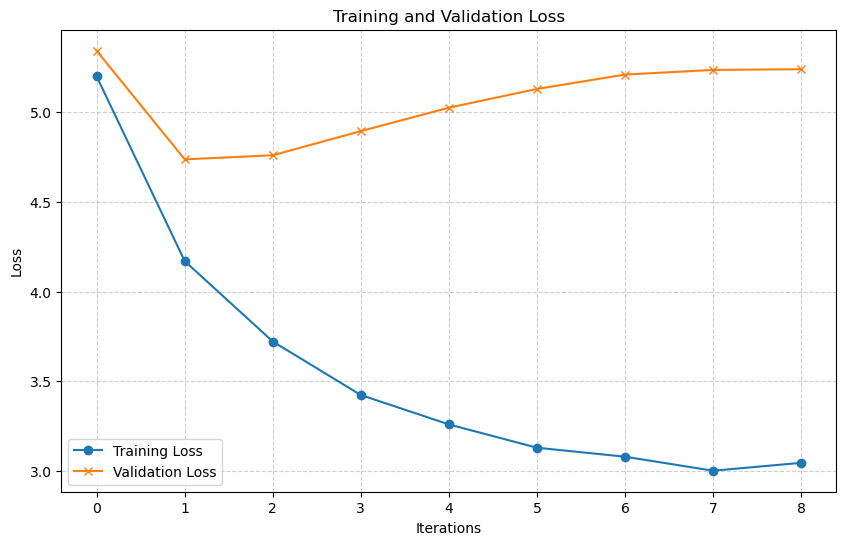

In [ ]:
import numpy as np
plt.figure(figsize=(10, 6))

# Plot losses and val_losses
plt.plot(lossesi, losses, label="Training Loss", marker='o')
plt.plot(lossesi, val_losses, label="Validation Loss", marker='x')

# Add grid lines, labels, and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [ ]:
import time
def sample(n, context=""):
    model.eval()
    result = tokenizer.encode(context)[-block_size:]  # truncate
    with torch.no_grad():
        for _ in range(n):
            x = torch.tensor(result, dtype=torch.long).unsqueeze(0).to(device)
            logits, _ = model(x)
            probs = F.softmax(logits[:,-1,:], dim=-1)
            idx = torch.multinomial(probs, num_samples=1).item()
            result.append(idx)
            result = result[-block_size:]
    return tokenizer.decode(torch.tensor(result))

print(sample(100, context="Thy"))


Thy cardt you. So to sab earen i am too
Wifey < 3 : Miss you
Nitin : Lay karo ulti thi peme banla karungi mai waha
Wifey < 3 : :). I ’ m 278okcure and Eermaleles
Wifey < 3 : Okay
Nitin : Cab fir bril
Wifey < 3 : Haan ho jayega aa jana. Chaliye. Kahan ho. Batana. Neend aa rahi hu main. Fushbin


In [ ]:
@torch.no_grad()
def sample(model, tokenizer, prompt, max_new_tokens=100, temperature=1.0, top_k=None, device='cuda'):
    model.eval()
    
    # Encode initial context
    context_ids = tokenizer.encode(prompt)
    context = torch.tensor(context_ids, dtype=torch.long, device=device).unsqueeze(0)  # [1, T]

    for _ in range(max_new_tokens):
        # Truncate to last block_size tokens
        context_cond = context[:, -block_size:]

        # Forward pass to get logits
        logits, _ = model(context_cond)
        logits = logits[:,-1,:] / temperature  # take last token's logits

        if top_k:
            v, ix = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = -float('Inf')

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)

        # Append sampled token
        context = torch.cat((context, next_id), dim=1)

    out_ids = context.squeeze().tolist()
    return tokenizer.decode(out_ids)

sample_text = sample(model, tokenizer, "E", max_new_tokens=522, temperature=0.85, top_k=10)
print(sample_text)

Everyone as the quace and more one likeing. I am just glld of any the bridge and Hindo, Hinder, we can are ' t have you can have been rideed on the before home we need to you dont talk about this is will be eointment on the Hindi company in the bangalore, app attemli. Bheevy - 8698350. https :// www. amazon. com / 32. 944964957305179212468 & sr_pre_blocks = 44806 - 76 - 01 - 2023 - 04 & checkout = 2023 - 02 - 13 ; dest_id = ।।।. Nitin :
Nitin : https :// www. reddit. com / r / aww / comments / bt9s / comments / d /horw - again - - inverased - li - in - Garima - loes - 7 - 75. https :// www. youtube. com / watch? v = dwRMxI? feature = share. Rchd. https :// www. reddit. com / r / Instagramreality / comments / d7wl - cot / i_or_the_fough_his_por_is_went_entt_this_bou_his_fl_prer_who_in /? utm_source = share & utm_medium = ios_app & utm_name = iossmf. https :// www. reddit. com / r / Instagramreality / comments / bt8bk / si_parcts /? utm_source = share & utm_medium = ios_app. https :// ww